# Reliability Diagram -- Training Year, Validation Split & Both Test-Year Halves

Same methodology as `forecast_diagnostics.ipynb` Section 2 (test year), run here on four
other periods for comparison:

1. **2018 training split** -- an in-sample calibration check. Baseline, the CRPS-only
   control, and both DFL arms were all trained (or warm-started and fine-tuned) directly
   on this data.
2. **Validation split** (2019-01-01 to 2019-06-30) -- the early-stopping signal every
   forecaster's training was actually selected against, but never directly optimised on
   -- a genuinely held-out-during-training check, distinct from both the in-sample
   training-year result and the fully-sealed test year.
3. **First half of the sealed test year** (2019-07-01 to 2019-12-30, 183 of 366 days) --
   checks whether calibration is stable across the test year itself, or whether it drifts/
   differs between the two halves (e.g. summer-heavy vs. winter-heavy solar seasonality).
4. **Second half of the sealed test year** (2019-12-31 to 2020-06-30, the remaining 183
   days) -- the direct H1/H2 comparison this makes possible.

All four reuse `train_dfl_forecasts.load_data()`'s `train_windows`/`val_windows` and
`eval_raw.load_test_windows()` directly -- identical feature pipeline/imputation to every
other analysis in this project.

## Setup

In [1]:
from __future__ import annotations
import sys
import dataclasses
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
sys.path.insert(0, str(here() / "7_model_training"))
from eval_raw import (
    load_test_windows, forecast_quantiles, fresh_baseline_model, dfl_model_from,
    FORECASTING_DIR, DFL_TRAIN_DIR, QUANTILE_LEVELS,
)
from train_dfl_forecasts import load_data

SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]
DEFAULT_SEED = 20240801
FAMILY_BASE_ID = {
    "Baseline": None,
    "Control": "crps_only_retrained",
    "DFL Single-price": "dfl_1stage_single-price",
    "DFL Dual-price": "dfl_1stage_dual-price",
}
FAMILY_ORDER = list(FAMILY_BASE_ID)
FAMILY_COLORS = {"Baseline": "C0", "Control": "grey", "DFL Single-price": "C6", "DFL Dual-price": "C3"}


def seed_variant(base_id, seed):
    return base_id if seed == DEFAULT_SEED else f"{base_id}_seed{seed}"


print("loading windows...")
train_windows, val_windows = load_data()
test_windows = load_test_windows()

n_test = len(test_windows.delivery_start)
half = n_test // 2
test_h1_windows = dataclasses.replace(
    test_windows,
    x_hist=test_windows.x_hist[:half], x_fut=test_windows.x_fut[:half],
    y=test_windows.y[:half], price=test_windows.price[:half] if test_windows.price is not None else None,
    delivery_start=test_windows.delivery_start[:half],
)
test_h2_windows = dataclasses.replace(
    test_windows,
    x_hist=test_windows.x_hist[half:], x_fut=test_windows.x_fut[half:],
    y=test_windows.y[half:], price=test_windows.price[half:] if test_windows.price is not None else None,
    delivery_start=test_windows.delivery_start[half:],
)

print(f"n_train_days={len(train_windows.delivery_start)}")
print(f"n_val_days={len(val_windows.delivery_start)}  "
      f"(range {val_windows.delivery_start[0].date()} to {val_windows.delivery_start[-1].date()})")
print(f"n_test_days={n_test}  (full range {test_windows.delivery_start[0].date()} to {test_windows.delivery_start[-1].date()})")
print(f"n_test_h1_days={len(test_h1_windows.delivery_start)}  "
      f"(range {test_h1_windows.delivery_start[0].date()} to {test_h1_windows.delivery_start[-1].date()})")
print(f"n_test_h2_days={len(test_h2_windows.delivery_start)}  "
      f"(range {test_h2_windows.delivery_start[0].date()} to {test_h2_windows.delivery_start[-1].date()})")

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = baseline_ckpt["scaler_stats"]
baseline_model = fresh_baseline_model(baseline_ckpt)


def load_dfl(forecaster_id):
    ck = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    return dfl_model_from(baseline_ckpt, ck)

loading windows...
[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)


[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
n_train_days=365
n_val_days=181  (range 2019-01-01 to 2019-06-30)
n_test_days=366  (full range 2019-07-01 to 2020-06-30)
n_test_h1_days=183  (range 2019-07-01 to 2019-12-30)
n_test_h2_days=183  (range 2019-12-31 to 2020-06-30)


### Shared quantile collection + reliability-diagram helpers

Parameterised by `windows` so the same collection/plotting code runs against either
period without duplication.

In [2]:
def collect_quantiles(model, windows):
    """(n_days, 24, Q) forecast quantiles and (n_days, 24) realised, over `windows`."""
    n = len(windows.delivery_start)
    q_all = np.empty((n, 24, len(QUANTILE_LEVELS)))
    y_all = np.empty((n, 24))
    for d in range(n):
        q_all[d] = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d]).numpy()
        y_all[d] = np.asarray(windows.y[d], float)
    return q_all, y_all


def build_cache(windows):
    cache = {}
    for family in FAMILY_ORDER:
        base_id = FAMILY_BASE_ID[family]
        seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
        for seed in seeds:
            model = baseline_model if family == "Baseline" else load_dfl(seed_variant(base_id, seed))
            cache[(family, seed)] = collect_quantiles(model, windows)
            print(f"  collected {family} seed={seed}", flush=True)
    return cache


def empirical_coverage(q_all, y_all):
    """(Q,) empirical coverage -- fraction of all (day, hour) observations <= each
    quantile level's forecast, pooled over the given period."""
    y_flat = y_all.reshape(-1)
    q_flat = q_all.reshape(-1, q_all.shape[-1])
    return (y_flat[:, None] <= q_flat).mean(axis=0)


def family_coverage_stats(family, cache):
    seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
    covs = np.array([empirical_coverage(*cache[(family, seed)]) for seed in seeds])
    return covs.mean(axis=0), (covs.std(axis=0) if len(seeds) > 1 else None)


def plot_reliability(cache, title):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True, sharex=True)
    diag = np.array([0.0, 1.0])
    for ax, family in zip(axes, FAMILY_ORDER):
        cov_mean, cov_std = family_coverage_stats(family, cache)
        ax.plot(diag, diag, "k--", linewidth=1, label="perfect calibration")
        ax.plot(QUANTILE_LEVELS, cov_mean, "-o", color=FAMILY_COLORS[family], markersize=3, label="empirical coverage")
        if cov_std is not None:
            ax.fill_between(QUANTILE_LEVELS, cov_mean - cov_std, cov_mean + cov_std,
                             color=FAMILY_COLORS[family], alpha=0.2)
        ax.set_title(family, fontsize=10)
        ax.set_xlabel("nominal quantile level")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(linestyle="--", linewidth=0.6, alpha=0.5)
        ax.legend(fontsize=7, loc="upper left")
    axes[0].set_ylabel("empirical coverage")
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()

## Reliability diagram -- training year (2018)

  collected Baseline seed=20240801


  collected Control seed=20240801


  collected Control seed=20240802


  collected Control seed=20240803


  collected Control seed=20240804


...

  collected DFL Dual-price seed=20240801


  collected DFL Dual-price seed=20240802


  collected DFL Dual-price seed=20240803


  collected DFL Dual-price seed=20240804


  collected DFL Dual-price seed=20240805


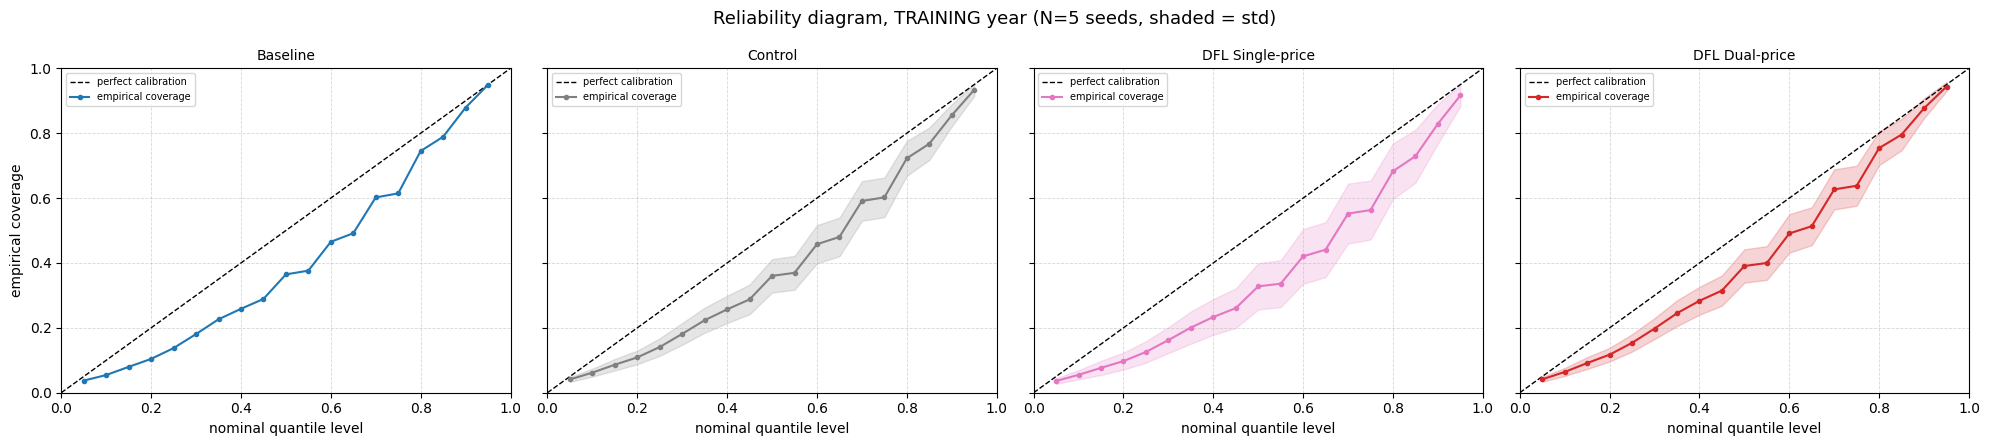

In [3]:
cache_train = build_cache(train_windows)
plot_reliability(cache_train, "Reliability diagram, TRAINING year (N=5 seeds, shaded = std)")

## Reliability diagram -- validation split (2019-01 to 2019-06)

  collected Baseline seed=20240801


  collected Control seed=20240801


  collected Control seed=20240802


  collected Control seed=20240803


  collected Control seed=20240804


...

  collected DFL Dual-price seed=20240801


  collected DFL Dual-price seed=20240802


  collected DFL Dual-price seed=20240803


  collected DFL Dual-price seed=20240804


  collected DFL Dual-price seed=20240805


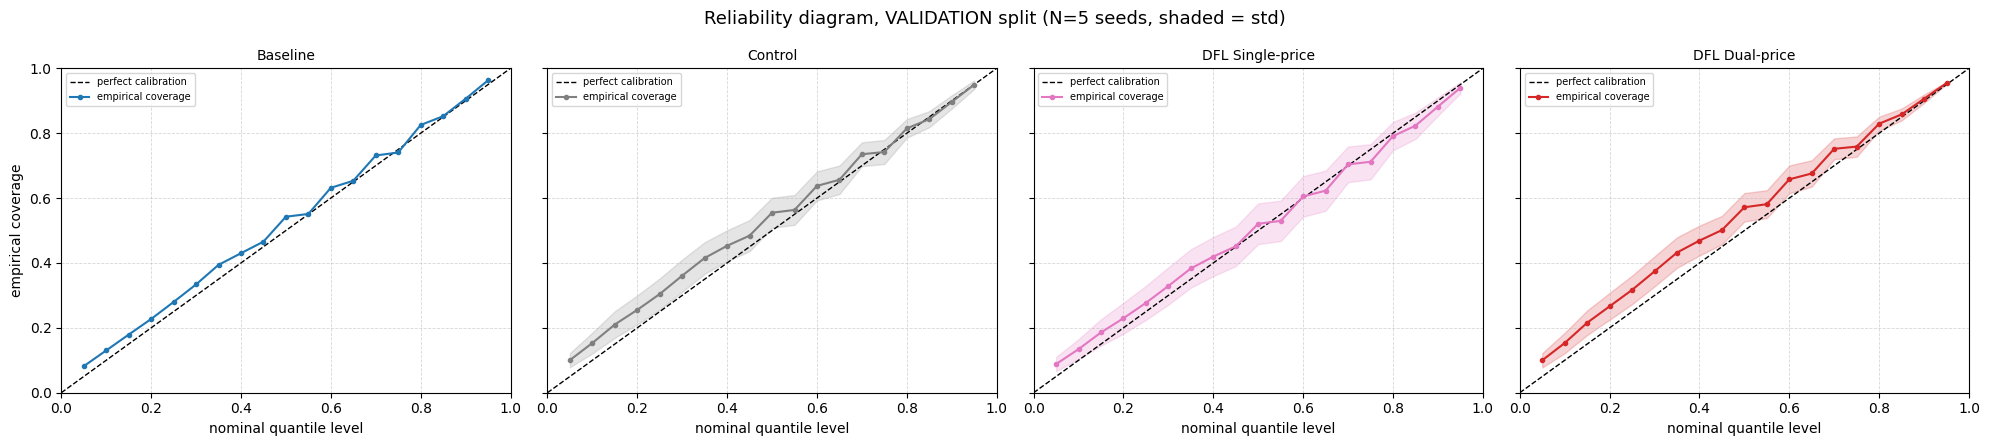

In [4]:
cache_val = build_cache(val_windows)
plot_reliability(cache_val, "Reliability diagram, VALIDATION split (N=5 seeds, shaded = std)")

## Reliability diagram -- first half of test year (2019-07 to 2019-12)

  collected Baseline seed=20240801


  collected Control seed=20240801


  collected Control seed=20240802


  collected Control seed=20240803


  collected Control seed=20240804


...

  collected DFL Dual-price seed=20240801


  collected DFL Dual-price seed=20240802


  collected DFL Dual-price seed=20240803


  collected DFL Dual-price seed=20240804


  collected DFL Dual-price seed=20240805


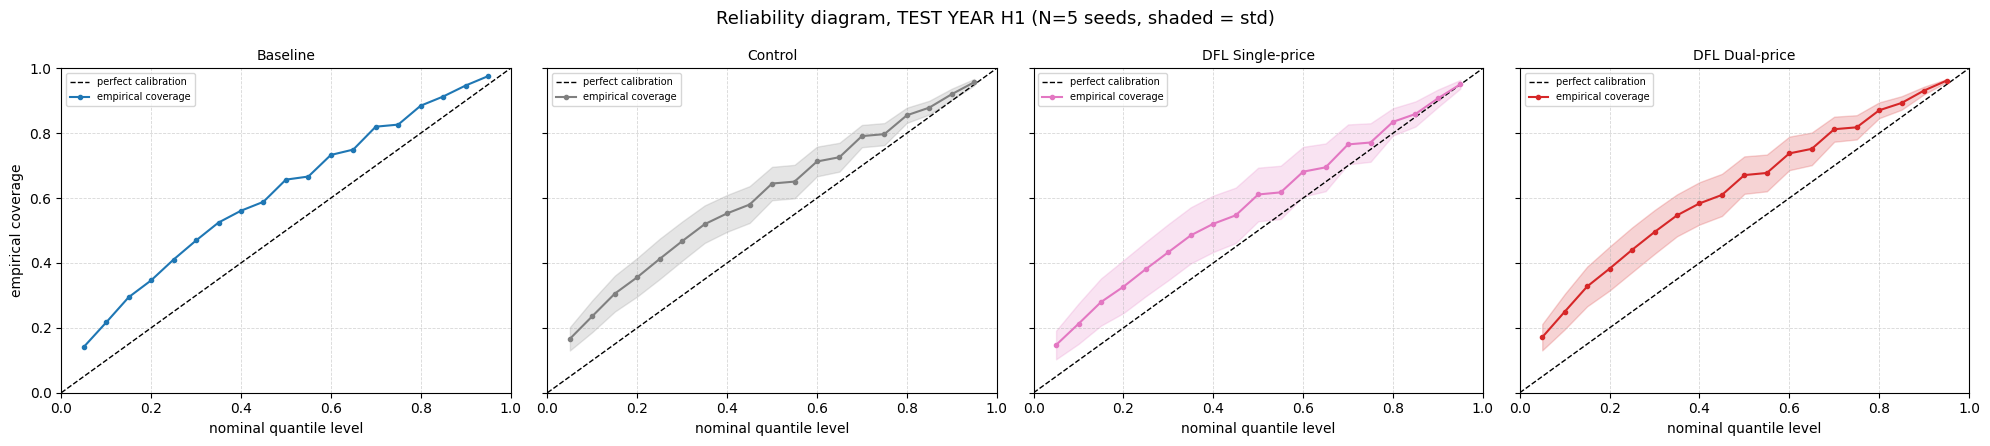

In [5]:
cache_test_h1 = build_cache(test_h1_windows)
plot_reliability(cache_test_h1, "Reliability diagram, TEST YEAR H1 (N=5 seeds, shaded = std)")

## Reliability diagram -- second half of test year (2019-12 to 2020-06)

  collected Baseline seed=20240801


  collected Control seed=20240801


  collected Control seed=20240802


  collected Control seed=20240803


  collected Control seed=20240804


...

  collected DFL Dual-price seed=20240801


  collected DFL Dual-price seed=20240802


  collected DFL Dual-price seed=20240803


  collected DFL Dual-price seed=20240804


  collected DFL Dual-price seed=20240805


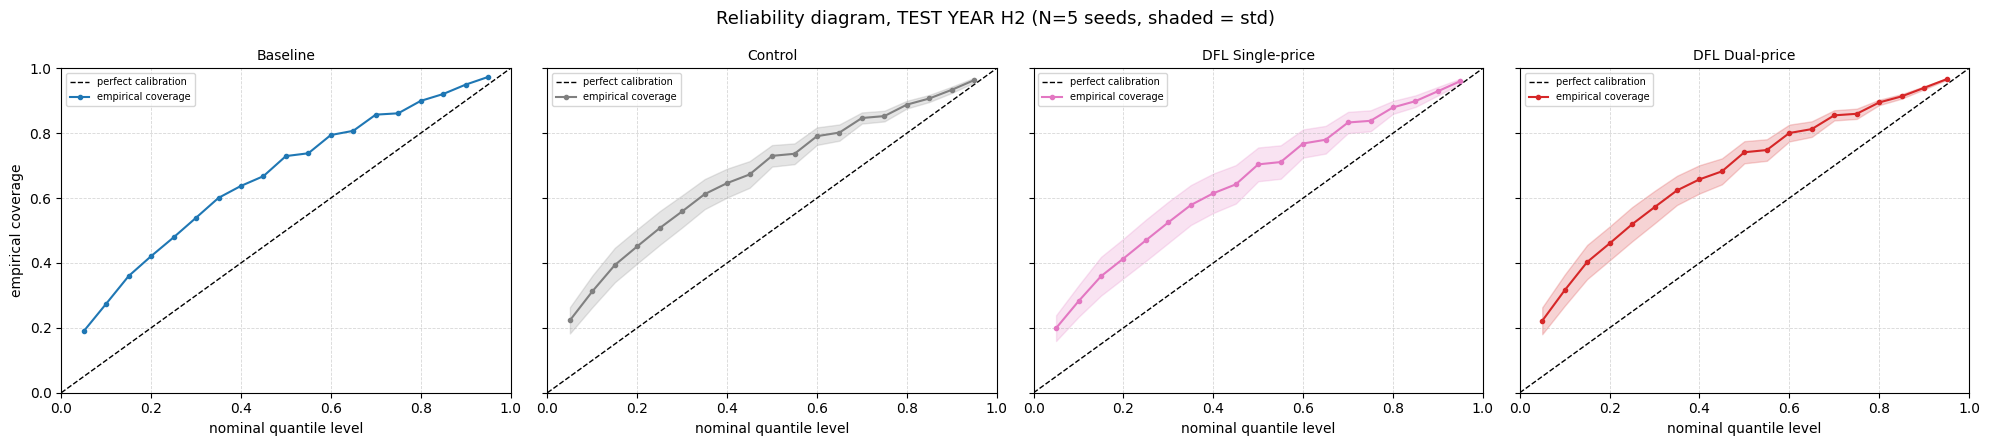

In [6]:
cache_test_h2 = build_cache(test_h2_windows)
plot_reliability(cache_test_h2, "Reliability diagram, TEST YEAR H2 (N=5 seeds, shaded = std)")